## Etapa 1

In [1]:
def load_images(input_dir, shuffle=True):
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    filenames = sorted(f for f in os.listdir(input_dir) if f.lower().endswith(valid_ext))
    if shuffle:
        random.shuffle(filenames)

    images, kept_names = [], []
    for fname in filenames:
        img = cv2.imread(os.path.join(input_dir, fname))
        if img is None:
            print(f"Aviso: nao foi possivel ler {fname}, ignorando.")
            continue
        images.append(img)
        kept_names.append(fname)

    print("Ordem de leitura (embaralhada; usada so para referencia/depuracao do usuario):")
    for i, f in enumerate(kept_names):
        print(f"  indice {i}: {f}")

    return images, kept_names

## Etapa 2

In [2]:
def create_detector(method="SIFT"):
    method = method.upper()
    if method == "SIFT":
        return cv2.SIFT_create()
    elif method == "ORB":
        return cv2.ORB_create(nfeatures=4000)
    else:
        raise ValueError(f"Detector desconhecido: {method}")


def detect_features(image, method="SIFT"):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    detector = create_detector(method)
    keypoints, descriptors = detector.detectAndCompute(gray, None)
    return keypoints, descriptors


def detect_features_all(images, method="SIFT"):
    all_kps, all_descs = [], []
    for img in images:
        kps, descs = detect_features(img, method)
        all_kps.append(kps)
        all_descs.append(descs)
    return all_kps, all_descs


def draw_keypoints(image, keypoints, out_path=None):
    vis = cv2.drawKeypoints(
        image, keypoints, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    if out_path:
        cv2.imwrite(out_path, vis)
    return vis


def compare_detectors(image, methods=("SIFT", "ORB"), out_dir=None):
    summary = {}
    for m in methods:
        kps, _ = detect_features(image, m)
        summary[m] = len(kps)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
            draw_keypoints(image, kps, os.path.join(out_dir, f"keypoints_{m}.png"))
    return summary

## Etapa 3

In [3]:
def create_matcher(method="SIFT"):
    """FLANN para descritores float (SIFT); BFMatcher com Hamming para binarios (ORB/AKAZE)."""
    method = method.upper()
    if method == "SIFT":
        index_params = dict(algorithm=1, trees=5)  # FLANN_INDEX_KDTREE
        search_params = dict(checks=50)
        return cv2.FlannBasedMatcher(index_params, search_params)
    else:  # ORB, AKAZE -> descritores binarios
        return cv2.BFMatcher(cv2.NORM_HAMMING)


def match_features(descs1, descs2, method="SIFT", ratio_thresh=0.75):
    """
    Emparelha descritores entre duas imagens usando k-NN (k=2) e aplica o
    ratio test de Lowe (Etapa 3.2). Retorna a lista de cv2.DMatch aprovados,
    ordenada por distancia (melhores primeiro).
    """
    if descs1 is None or descs2 is None or len(descs1) < 2 or len(descs2) < 2:
        return []

    matcher = create_matcher(method)
    if method.upper() != "SIFT":
        descs1 = descs1.astype(np.uint8)
        descs2 = descs2.astype(np.uint8)
    else:
        descs1 = descs1.astype(np.float32)
        descs2 = descs2.astype(np.float32)

    knn_matches = matcher.knnMatch(descs1, descs2, k=2)

    good = []
    for pair in knn_matches:
        if len(pair) != 2:
            continue
        m, n = pair
        if m.distance < ratio_thresh * n.distance:
            good.append(m)

    good.sort(key=lambda m: m.distance)
    return good


def draw_matches(img1, kps1, img2, kps2, matches, out_path=None, max_draw=100):
    """Etapa 3.3 - visualiza linhas conectando os keypoints casados."""
    vis = cv2.drawMatches(
        img1, kps1, img2, kps2, matches[:max_draw], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    if out_path:
        cv2.imwrite(out_path, vis)
    return vis

## Etapa 4

In [4]:
def count_inliers(kps1, descs1, kps2, descs2, method="SIFT", ratio_thresh=0.75,
                   ransac_thresh=4.0, min_matches=8):
    """
    Conta o numero de correspondencias inliers entre duas imagens apos ajuste
    de homografia com RANSAC. Retorna (n_inliers, matches_bons, H).
    H mapeia pontos da imagem 1 para o referencial da imagem 2.
    """
    good = match_features(descs1, descs2, method, ratio_thresh)
    if len(good) < min_matches:
        return 0, good, None

    pts1 = np.float32([kps1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    pts2 = np.float32([kps2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, ransac_thresh)
    if H is None:
        return 0, good, None

    n_inliers = int(mask.sum())
    return n_inliers, good, H


def build_connectivity_matrix(images, method="SIFT", ratio_thresh=0.75,
                               ransac_thresh=4.0, min_matches=8):
    """
    Constroi a matriz N x N com o numero de inliers entre cada par de imagens.
    Tambem retorna keypoints/descritores ja calculados (reaproveitados nas
    etapas seguintes) e as homografias estimadas para cada par conectado
    (armazenadas apenas como homographies[(i, j)] com i < j, mapeando i -> j).
    """
    n = len(images)
    all_kps, all_descs = [], []
    for img in images:
        kps, descs = detect_features(img, method)
        all_kps.append(kps)
        all_descs.append(descs)

    connectivity = np.zeros((n, n), dtype=int)
    homographies = {}
    for i in range(n):
        for j in range(i + 1, n):
            n_inliers, _, H = count_inliers(
                all_kps[i], all_descs[i], all_kps[j], all_descs[j],
                method, ratio_thresh, ransac_thresh, min_matches,
            )
            connectivity[i, j] = n_inliers
            connectivity[j, i] = n_inliers
            if H is not None:
                homographies[(i, j)] = H  # mapeia i -> j

    return connectivity, all_kps, all_descs, homographies


def build_neighbor_graph(connectivity, min_inliers=20):
    """
    Converte a matriz de conectividade em um grafo de adjacencia (dict de
    listas de (vizinho, peso)), mantendo apenas pares cuja contagem de
    inliers ultrapassa min_inliers.
    """
    n = connectivity.shape[0]
    graph = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(n):
            if i != j and connectivity[i, j] >= min_inliers:
                graph[i].append((j, connectivity[i, j]))
    return graph


def detect_intruders(graph):
    """Imagens sem nenhuma conexao valida sao consideradas intrusas (Etapa 4.4)."""
    return [node for node, neighbors in graph.items() if len(neighbors) == 0]


def pick_start_node(sub_graph, valid_nodes):
    """
    Escolhe uma extremidade do panorama para iniciar a ordenacao.

    So o menor grau nao basta: com sobreposicoes "de pulo" (imagem i casando
    com i+2) varios nos empatam e a busca pode comecar no meio da sequencia.
    Aqui usamos ordenacao espectral: o vetor de Fiedler (2o autovetor do
    Laplaciano do grafo ponderado pelos inliers) varia de forma monotona ao
    longo de uma cadeia, entao seu valor extremo corresponde a uma ponta.
    """
    if len(valid_nodes) < 3:
        return min(valid_nodes, key=lambda n: len(sub_graph[n]))
    idx = {n: k for k, n in enumerate(valid_nodes)}
    W = np.zeros((len(valid_nodes), len(valid_nodes)))
    for n in valid_nodes:
        for nb, w in sub_graph[n]:
            W[idx[n], idx[nb]] = w
    W = np.maximum(W, W.T)
    laplacian = np.diag(W.sum(axis=1)) - W
    _, eigvecs = np.linalg.eigh(laplacian)
    fiedler = eigvecs[:, 1]
    return valid_nodes[int(np.argmin(fiedler))]



def infer_order(graph, valid_nodes):
    """
    Infere a sequencia de captura a partir do grafo de vizinhanca (Etapa 4.3).

    Heuristica: parte do no de menor grau (tende a ser uma extremidade do
    panorama, ja que imagens do meio se conectam a duas vizinhas e as das
    pontas a apenas uma) e caminha sempre para o vizinho nao visitado de
    maior peso (mais inliers = conexao mais confiavel). Assume topologia
    aproximadamente linear, como a captura em faixa da Figura 1.
    """
    if not valid_nodes:
        return []

    sub_graph = {n: [(nb, w) for nb, w in graph[n] if nb in valid_nodes] for n in valid_nodes}

    start = pick_start_node(sub_graph, valid_nodes)

    order = [start]
    visited = {start}
    current = start
    while len(order) < len(valid_nodes):
        candidates = [(nb, w) for nb, w in sub_graph[current] if nb not in visited]
        if not candidates:
            remaining = [n for n in valid_nodes if n not in visited]
            if not remaining:
                break
            # grafo desconectado: reinicia a partir de outro componente
            current = remaining[0]
            order.append(current)
            visited.add(current)
            continue
        next_node = max(candidates, key=lambda x: x[1])[0]
        order.append(next_node)
        visited.add(next_node)
        current = next_node

    return order

## Etapa 5

In [5]:
def estimate_homography(kps1, kps2, matches, ransac_thresh=4.0):
    """
    Estima H (que leva pontos de img1 para o referencial de img2) via RANSAC
    (Etapa 5.1). Retorna H, mascara de inliers e metricas (taxa de inliers,
    erro de reprojecao medio) pedidas na Etapa 5.3.
    """
    if len(matches) < 4:
        return None, None, {"inlier_ratio": 0.0, "mean_reproj_error": None,
                             "n_inliers": 0, "n_matches": len(matches)}

    pts1 = np.float32([kps1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kps2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, ransac_thresh)
    if H is None:
        return None, None, {"inlier_ratio": 0.0, "mean_reproj_error": None,
                             "n_inliers": 0, "n_matches": len(matches)}

    mask = mask.ravel().astype(bool)
    inlier_ratio = mask.sum() / len(matches)

    pts1_in = pts1[mask]
    pts2_in = pts2[mask]
    if len(pts1_in) > 0:
        pts1_proj = cv2.perspectiveTransform(pts1_in, H)
        errors = np.linalg.norm(pts1_proj - pts2_in, axis=2).ravel()
        mean_error = float(errors.mean())
    else:
        mean_error = None

    metrics = {
        "inlier_ratio": float(inlier_ratio),
        "mean_reproj_error": mean_error,
        "n_inliers": int(mask.sum()),
        "n_matches": len(matches),
    }
    return H, mask, metrics


def _get_H(a, b, homographies):
    """Retorna a homografia que mapeia a imagem `a` para o referencial de `b`,
    reaproveitando homographies[(a,b)] (a->b) ou invertendo homographies[(b,a)] (b->a)."""
    if (a, b) in homographies:
        return homographies[(a, b)]
    if (b, a) in homographies:
        return np.linalg.inv(homographies[(b, a)])
    return None


def compose_pairwise_homographies(order, homographies, ref_index=None):
    """
    Compoe homografias par-a-par para levar todas as imagens ao referencial
    de uma imagem de referencia (por padrao, a do meio da sequencia
    ordenada). Encadear transformacoes par-a-par e uma simplificacao do
    bundle adjustment global (ver Extra X1 do enunciado): erros pequenos em
    cada par se acumulam ao longo da cadeia.

    `homographies` e um dict {(i, j): H_i_para_j} vindo de
    ordering.build_connectivity_matrix. Retorna dict {indice_original: H_para_referencia}.
    """
    if not order:
        return {}
    if ref_index is None:
        ref_index = order[len(order) // 2]

    ref_pos = order.index(ref_index)
    H_to_ref = {ref_index: np.eye(3)}

    # propaga para a direita a partir da referencia
    for k in range(ref_pos, len(order) - 1):
        i, j = order[k], order[k + 1]
        if i not in H_to_ref:
            break  # cadeia quebrada (par sem homografia valida)
        H_i_to_j = _get_H(i, j, homographies)
        if H_i_to_j is None:
            continue
        H_to_ref[j] = H_to_ref[i] @ np.linalg.inv(H_i_to_j)

    # propaga para a esquerda a partir da referencia
    for k in range(ref_pos, 0, -1):
        i, j = order[k], order[k - 1]
        if i not in H_to_ref:
            break
        H_i_to_j = _get_H(i, j, homographies)
        if H_i_to_j is None:
            continue
        H_to_ref[j] = H_to_ref[i] @ np.linalg.inv(H_i_to_j)

    return H_to_ref

## Etapa 6

In [6]:
def get_canvas_bounds(images, H_list):
    """Calcula o tamanho do canvas e a translacao necessaria para acomodar
    todas as imagens warpeadas no referencial comum, sem cortar nada."""
    all_corners = []
    for img, H in zip(images, H_list):
        h, w = img.shape[:2]
        corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
        warped_corners = cv2.perspectiveTransform(corners, H)
        all_corners.append(warped_corners)
    all_corners = np.concatenate(all_corners, axis=0)

    x_min, y_min = np.floor(all_corners.min(axis=0).ravel()).astype(int)
    x_max, y_max = np.ceil(all_corners.max(axis=0).ravel()).astype(int)

    translation = np.array([[1, 0, -x_min], [0, 1, -y_min], [0, 0, 1]], dtype=np.float64)
    canvas_size = (int(x_max - x_min), int(y_max - y_min))  # (largura, altura)
    return canvas_size, translation


def warp_to_canvas(img, H, translation, canvas_size):
    """Aplica H (para o referencial de composicao) + translacao, gerando a
    imagem e sua mascara de pixels validos no tamanho do canvas (Etapa 5.2)."""
    H_total = translation @ H
    warped = cv2.warpPerspective(img, H_total, canvas_size)
    mask = cv2.warpPerspective(
        np.full(img.shape[:2], 255, dtype=np.uint8), H_total, canvas_size
    )
    return warped, mask


def naive_composite(warped_images, masks):
    """Etapa 6.1 (versao ingenua) - media simples nas regioes de sobreposicao.
    Serve de baseline para evidenciar os fantasmas."""
    h, w = masks[0].shape
    acc = np.zeros((h, w, 3), dtype=np.float64)
    count = np.zeros((h, w, 1), dtype=np.float64)
    for warped, mask in zip(warped_images, masks):
        m = (mask > 0).astype(np.float64)[..., None]
        acc += warped.astype(np.float64) * m
        count += m
    count[count == 0] = 1
    return (acc / count).astype(np.uint8)


def find_optimal_seam(cost_map, valid_mask):
    """
    Encontra, via programacao dinamica (estilo seam carving), o caminho de
    topo a base de custo minimo dentro da regiao de sobreposicao
    (`valid_mask`). Pixels fora da mascara recebem custo infinito. Retorna
    um array 1D com a posicao x (local, dentro do recorte) da costura para
    cada linha y.
    """
    h, w = cost_map.shape
    INF = 1e9
    cost = np.where(valid_mask, cost_map, INF).astype(np.float64)

    dp = cost.copy()
    backtrack = np.zeros((h, w), dtype=np.int8)

    for y in range(1, h):
        up = dp[y - 1]
        left = np.roll(up, 1)
        left[0] = INF
        right = np.roll(up, -1)
        right[-1] = INF
        # ordem [up, left, right]: em caso de empate, argmin prefere manter a
        # coluna (offset 0), evitando zigue-zague desnecessario em regioes de
        # custo uniforme e produzindo costuras mais suaves
        stacked = np.stack([up, left, right], axis=0)
        best_idx = np.argmin(stacked, axis=0)
        dp[y] = cost[y] + stacked[best_idx, np.arange(w)]
        offset_map = np.array([0, -1, 1])
        backtrack[y] = offset_map[best_idx]

    seam = np.zeros(h, dtype=int)
    seam[h - 1] = int(np.argmin(dp[h - 1]))
    for y in range(h - 2, -1, -1):
        seam[y] = seam[y + 1] + backtrack[y + 1, seam[y + 1]]
        seam[y] = int(np.clip(seam[y], 0, w - 1))

    return seam


def blend_pair_with_seam(base, base_mask, new_img, new_mask, feather_width=15):
    """
    Combina `base` (panorama acumulado ate agora) com `new_img` (proxima
    imagem warpeada), removendo fantasmas com costura otima na regiao de
    sobreposicao e suavizando a transicao com feathering linear ao redor
    da costura.
    """
    overlap = (base_mask > 0) & (new_mask > 0)
    only_new = (new_mask > 0) & (~overlap)

    result = base.copy()
    result[only_new] = new_img[only_new]

    if not overlap.any():
        return result, (base_mask | new_mask)

    ys, xs = np.where(overlap)
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1

    base_roi = base[y0:y1, x0:x1].astype(np.float64)
    new_roi = new_img[y0:y1, x0:x1].astype(np.float64)
    overlap_roi = overlap[y0:y1, x0:x1]

    cost_map = np.sum((base_roi - new_roi) ** 2, axis=2)
    seam_x = find_optimal_seam(cost_map, overlap_roi)  # posicao x local da costura, por linha

    hloc, wloc = overlap_roi.shape
    xx = np.tile(np.arange(wloc), (hloc, 1))
    seam_col = seam_x.reshape(-1, 1)
    dist = xx - seam_col  # > 0 => lado da nova imagem; < 0 => lado da base
    weight = np.clip((dist + feather_width / 2) / feather_width, 0, 1)

    blended_roi = base_roi * (1 - weight[..., None]) + new_roi * weight[..., None]
    blended_roi = np.where(overlap_roi[..., None], blended_roi, base_roi)

    result[y0:y1, x0:x1][overlap_roi] = blended_roi[overlap_roi].astype(np.uint8)

    combined_mask = base_mask | new_mask
    return result, combined_mask


def compose_panorama(images, H_list, feather_width=15, remove_ghosts=True):
    """
    Pipeline completo da Etapa 6: calcula o canvas comum, warpa todas as
    imagens e as compoe sequencialmente. Retorna (panorama_final,
    panorama_ingenuo) para a comparacao lado a lado pedida na Etapa 6.4.
    """
    canvas_size, translation = get_canvas_bounds(images, H_list)

    warped_list, mask_list = [], []
    for img, H in zip(images, H_list):
        warped, mask = warp_to_canvas(img, H, translation, canvas_size)
        warped_list.append(warped)
        mask_list.append(mask)

    naive = naive_composite(warped_list, mask_list)

    if not remove_ghosts:
        return naive.copy(), naive

    panorama = warped_list[0].copy()
    panorama_mask = mask_list[0].copy()
    for warped, mask in zip(warped_list[1:], mask_list[1:]):
        panorama, panorama_mask = blend_pair_with_seam(
            panorama, panorama_mask, warped, mask, feather_width
        )

    return panorama, naive

## Teste

In [7]:
import os
import glob
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

INPUT_DIR = "D1_png"        
OUTPUT_DIR = "resultados"    
DETECTOR = "SIFT"           
random.seed(0)               


def show_image(img_bgr, title=None, figsize=(18, 8)):
    """Mostra uma imagem BGR (OpenCV) no notebook."""
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


def check_canvas_size(images, H_list, max_side=25000, max_pixels=60_000_000):
    """Evita estourar a memoria quando alguma homografia fica degenerada."""
    (w, h), _ = get_canvas_bounds(images, H_list)
    if w > max_side or h > max_side or w * h > max_pixels:
        raise RuntimeError(
            f"Canvas com tamanho absurdo ({w}x{h}): alguma homografia ficou degenerada. "
            "Verifique a ordem inferida, aumente min_inliers ou remova imagens problematicas."
        )
    return w, h


def choose_reference_image(order, homographies, images):
    """
    Testa cada imagem como referencia (Etapa 5) e escolhe a que mantem mais imagens
    na cadeia e gera o MENOR canvas -- ou seja, a menor distorcao perspectiva nas
    pontas. Retorna (ref_index, H_to_ref).
    """
    best = None
    for ref in order:
        H_to_ref = compose_pairwise_homographies(order, homographies, ref_index=ref)
        chain = [i for i in order if i in H_to_ref]
        (w, h), _ = get_canvas_bounds([images[i] for i in chain], [H_to_ref[i] for i in chain])
        score = (-len(chain), w * h)
        if best is None or score < best[0]:
            best = (score, ref, H_to_ref)
    return best[1], best[2]

In [8]:
def run_pipeline(input_dir, output_dir, detector="SIFT", ratio_thresh=0.75,
                  ransac_thresh=4.0, min_matches=8, min_inliers=20,
                  feather_width=15, use_bundle_adjustment=False, ba_max_pts=300,
                  exposure_compensation=None):
    """
    Executa todas as etapas (1 a 6) a partir de uma pasta de imagens.
    Se use_bundle_adjustment=True, aplica o Extra 1 (bundle adjustment global)
    entre as Etapas 5 e 6. Se exposure_compensation for "gain", "blocks" ou
    "gain+blocks", aplica o Extra 3 na Etapa 6. Nesses casos as celulas dos
    Extras correspondentes precisam ter sido executadas antes.

    Retorna um dict com os resultados intermediarios (reaproveitados nos Extras).
    """
    os.makedirs(output_dir, exist_ok=True)

    # ---- Etapa 1: carregamento ----
    print("[Etapa 1] Carregando imagens...")
    images, filenames = load_images(input_dir)
    if len(images) < 2:
        raise ValueError(f"Sao necessarias pelo menos 2 imagens em '{input_dir}'.")
    if len(images) < 6:
        print(f"Aviso: o enunciado pede no minimo 6 imagens; foram carregadas {len(images)}.")

    # ---- Etapa 2: deteccao de caracteristicas ----
    print("\n[Etapa 2] Detectando caracteristicas...")
    kp_dir = os.path.join(output_dir, "etapa2_keypoints")
    os.makedirs(kp_dir, exist_ok=True)
    summary = compare_detectors(images[0], out_dir=kp_dir)
    print(f"  Comparacao de detectores na primeira imagem (n. de keypoints): {summary}")

    all_kps_preview, _ = detect_features_all(images, method=detector)
    for i, (img, kps) in enumerate(zip(images, all_kps_preview)):
        draw_keypoints(img, kps, os.path.join(kp_dir, f"img{i}_{detector}.png"))

    # ---- Etapa 4 (usa Etapa 3 internamente): matriz de conectividade + ordenacao ----
    print("\n[Etapa 4] Construindo matriz de conectividade (todos os pares)...")
    connectivity, all_kps, all_descs, homographies = build_connectivity_matrix(
        images, method=detector, ratio_thresh=ratio_thresh,
        ransac_thresh=ransac_thresh, min_matches=min_matches,
    )
    print("Matriz de conectividade (n. de inliers por par):")
    print(connectivity)
    np.savetxt(os.path.join(output_dir, "matriz_conectividade.csv"), connectivity, fmt="%d", delimiter=",")

    graph = build_neighbor_graph(connectivity, min_inliers=min_inliers)
    intruders = detect_intruders(graph)
    if intruders:
        print("Imagens rejeitadas por falta de conectividade (candidatas a intrusas): "
              f"{[filenames[i] for i in intruders]}")
    else:
        print("Nenhuma imagem foi rejeitada por conectividade insuficiente "
              "(ajuste min_inliers se uma intrusa nao foi detectada).")

    valid_nodes = [i for i in range(len(images)) if i not in intruders]
    order = infer_order(graph, valid_nodes)
    print(f"Ordem inferida (indices): {order}")
    print(f"Ordem inferida (arquivos): {[filenames[i] for i in order]}")

    # ---- Etapa 3: visualizacao do emparelhamento para os pares consecutivos da ordem ----
    print("\n[Etapa 3] Salvando visualizacoes de emparelhamento para pares consecutivos...")
    match_dir = os.path.join(output_dir, "etapa3_matches")
    os.makedirs(match_dir, exist_ok=True)
    for k in range(len(order) - 1):
        i, j = order[k], order[k + 1]
        good = match_features(all_descs[i], all_descs[j], detector, ratio_thresh)
        draw_matches(images[i], all_kps[i], images[j], all_kps[j], good,
                     os.path.join(match_dir, f"match_{k}_{filenames[i]}_x_{filenames[j]}.png"))
        print(f"  {filenames[i]} <-> {filenames[j]}: {len(good)} correspondencias apos ratio test")

    # ---- Etapa 5: homografias compostas para um referencial comum ----
    print("\n[Etapa 5] Estimando homografias e metricas de alinhamento...")
    ref_index, H_to_ref = choose_reference_image(order, homographies, images)
    print(f"  Imagem de referencia (menor canvas): {filenames[ref_index]}")
    for k in range(len(order) - 1):
        i, j = order[k], order[k + 1]
        good = match_features(all_descs[i], all_descs[j], detector, ratio_thresh)
        if len(good) >= min_matches:
            _, _, metrics = estimate_homography(all_kps[i], all_kps[j], good, ransac_thresh)
            print(f"  Par ({filenames[i]}, {filenames[j]}): {metrics}")

    # ---- Extra 1 (opcional): bundle adjustment global ----
    ba_info = None
    if use_bundle_adjustment:
        print("\n[Extra 1] Bundle adjustment global das homografias...")
        chain = [i for i in order if i in H_to_ref]
        pairs = collect_pair_correspondences(
            chain, all_kps, all_descs, connectivity, method=detector,
            ratio_thresh=ratio_thresh, ransac_thresh=ransac_thresh,
            min_inliers=min_inliers, max_pts_per_pair=ba_max_pts,
        )
        H_to_ref, ba_info = bundle_adjust_homographies(H_to_ref, pairs, ref_index, names=filenames)

    ordered_images = [images[i] for i in order if i in H_to_ref]
    ordered_H = [H_to_ref[i] for i in order if i in H_to_ref]
    if len(ordered_images) < len(order):
        skipped = [filenames[i] for i in order if i not in H_to_ref]
        print(f"Aviso: imagens fora da cadeia de homografias validas foram descartadas: {skipped}")

    # ---- Etapa 6: composicao, blending e remocao de fantasmas ----
    print("\n[Etapa 6] Compondo panorama final...")
    w, h = check_canvas_size(ordered_images, ordered_H)
    print(f"  Tamanho do canvas: {w}x{h}")
    exposure_info = None
    if exposure_compensation:
        panorama, naive, exposure_info = compose_panorama_exposure(
            ordered_images, ordered_H, feather_width=feather_width, mode=exposure_compensation,
            names=[filenames[i] for i in order if i in H_to_ref])
    else:
        panorama, naive = compose_panorama(ordered_images, ordered_H, feather_width=feather_width)

    suffix = ("_ba" if use_bundle_adjustment else "") + ("_exp" if exposure_compensation else "")
    cv2.imwrite(os.path.join(output_dir, f"panorama_ingenuo{suffix}.png"), naive)
    cv2.imwrite(os.path.join(output_dir, f"panorama_final{suffix}.png"), panorama)

    print(f"\nConcluido! Resultados salvos em: {output_dir}")
    print(f"  - panorama_ingenuo{suffix}.png   (composicao simples, evidencia fantasmas)")
    print(f"  - panorama_final{suffix}.png     (com remocao de fantasmas via costura + feathering)")
    print("  - matriz_conectividade.csv")
    print("  - etapa2_keypoints/, etapa3_matches/   (visualizacoes para o relatorio)")

    return {
        "images": images, "filenames": filenames, "order": order,
        "intruders": intruders, "connectivity": connectivity,
        "all_kps": all_kps, "all_descs": all_descs, "homographies": homographies,
        "ref_index": ref_index, "H_to_ref": H_to_ref, "ba_info": ba_info,
        "exposure_info": exposure_info,
        "panorama": panorama, "naive": naive,
        "params": dict(detector=detector, ratio_thresh=ratio_thresh,
                       ransac_thresh=ransac_thresh, min_inliers=min_inliers,
                       feather_width=feather_width, output_dir=output_dir),
    }

[Etapa 1] Carregando imagens...
Ordem de leitura (embaralhada; usada so para referencia/depuracao do usuario):
  indice 0: DSC03743.png
  indice 1: DSC03744.png
  indice 2: DSC03737.png
  indice 3: DSC03741.png
  indice 4: DSC03739.png
  indice 5: DSC03740.png
  indice 6: DSC03738.png
  indice 7: DSC03736.png
  indice 8: WhatsApp Image 2026-10-02 at 10.39.58.jpeg
  indice 9: DSC03742.png

[Etapa 2] Detectando caracteristicas...
  Comparacao de detectores na primeira imagem (n. de keypoints): {'SIFT': 9067, 'ORB': 4000}

[Etapa 4] Construindo matriz de conectividade (todos os pares)...
Matriz de conectividade (n. de inliers por par):
[[   0 3321    4 1592   63  312    7    8    9 2932]
 [3321    0    4  959    9  159    8   16    1 1635]
 [   4    4    0  447 2954 1157 5497 3017    8  225]
 [1592  959  447    0 1260 2946  516  197    8 4360]
 [  63    9 2954 1260    0 2669 3062 1502    5  617]
 [ 312  159 1157 2946 2669    0 1154  445    8 1301]
 [   7    8 5497  516 3062 1154    0 3052

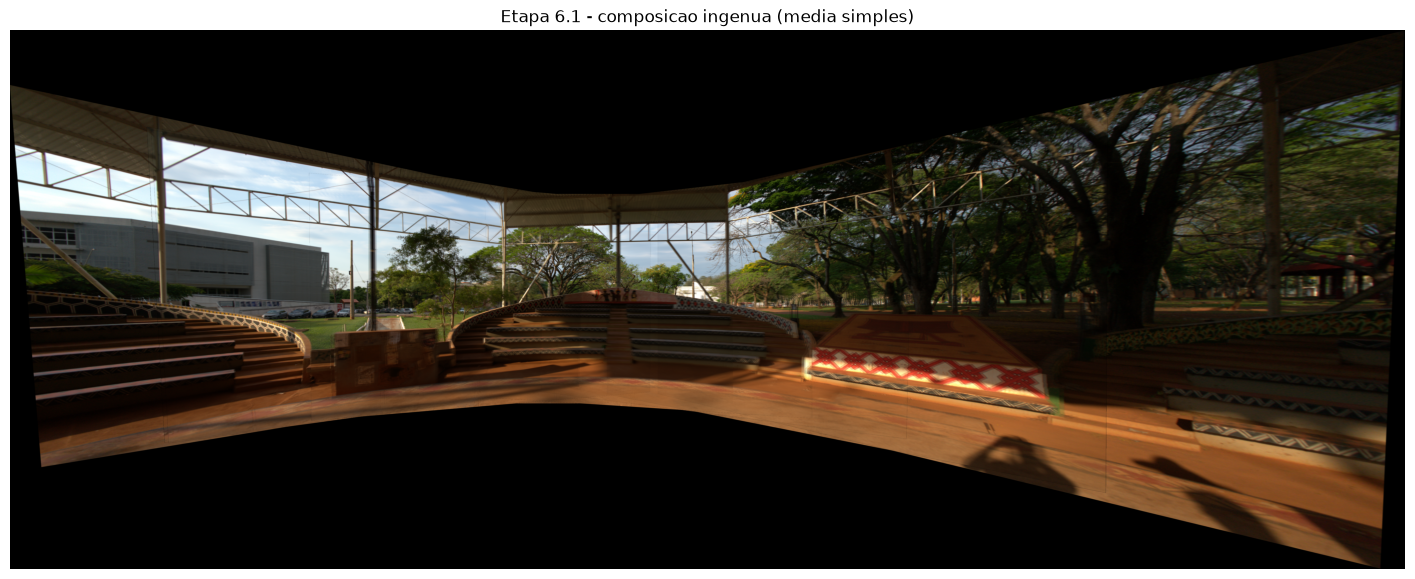

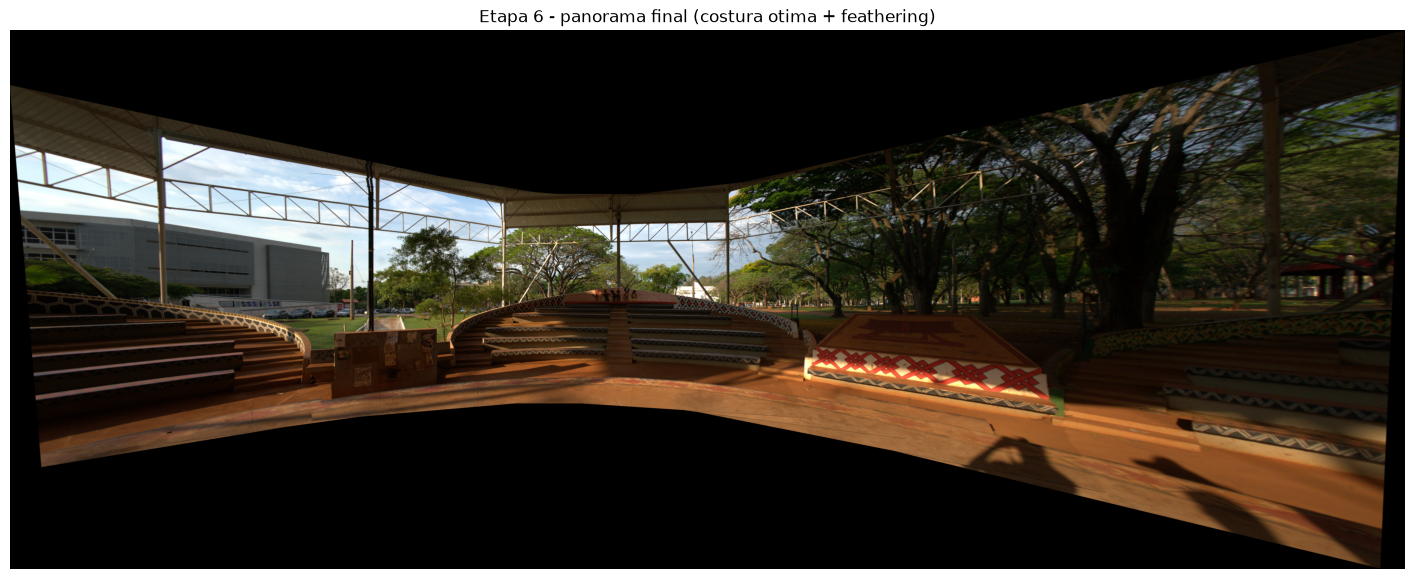

In [9]:
# ============================================================
# Executa todas as etapas (1 -> 6) na pasta INPUT_DIR
# ============================================================
resultado = run_pipeline(
    INPUT_DIR, OUTPUT_DIR,
    detector=DETECTOR,
    ratio_thresh=0.75,
    ransac_thresh=4.0,
    min_matches=8,
    min_inliers=20,
    feather_width=15,
)

show_image(resultado["naive"], "Etapa 6.1 - composicao ingenua (media simples)")
show_image(resultado["panorama"], "Etapa 6 - panorama final (costura otima + feathering)")

## Extras

### Extra 1

In [10]:
from scipy.optimize import least_squares
from scipy.sparse import lil_matrix


def _apply_homography(H, pts):
    """Aplica H (3x3) a pontos Nx2 (vetorizado)."""
    x, y = pts[:, 0], pts[:, 1]
    den = H[2, 0] * x + H[2, 1] * y + H[2, 2]
    den = np.where(np.abs(den) < 1e-12, 1e-12, den)
    u = (H[0, 0] * x + H[0, 1] * y + H[0, 2]) / den
    v = (H[1, 0] * x + H[1, 1] * y + H[1, 2]) / den
    return np.stack([u, v], axis=1)


def collect_pair_correspondences(nodes, all_kps, all_descs, connectivity, method="SIFT",
                                 ratio_thresh=0.75, ransac_thresh=4.0, min_inliers=20,
                                 max_pts_per_pair=300, seed=0):
    """
    Para todo par (a, b) de imagens validas que se sobrepoem (connectivity >= min_inliers),
    retorna as correspondencias INLIERS: dict {(a, b): (pts_a Nx2, pts_b Nx2)}.
    Subamostra ate max_pts_per_pair pontos por par para manter a otimizacao rapida.
    """
    rng = np.random.default_rng(seed)
    nodes = list(nodes)
    pairs = {}
    for ia in range(len(nodes)):
        for ib in range(ia + 1, len(nodes)):
            a, b = nodes[ia], nodes[ib]
            if connectivity[a, b] < min_inliers:
                continue
            good = match_features(all_descs[a], all_descs[b], method, ratio_thresh)
            if len(good) < 4:
                continue
            pa = np.float32([all_kps[a][m.queryIdx].pt for m in good])
            pb = np.float32([all_kps[b][m.trainIdx].pt for m in good])
            H, mask = cv2.findHomography(pa, pb, cv2.RANSAC, ransac_thresh)
            if H is None:
                continue
            inl = mask.ravel().astype(bool)
            pa, pb = pa[inl], pb[inl]
            if len(pa) < 4:
                continue
            if len(pa) > max_pts_per_pair:
                sel = rng.choice(len(pa), max_pts_per_pair, replace=False)
                pa, pb = pa[sel], pb[sel]
            pairs[(a, b)] = (pa.astype(np.float64), pb.astype(np.float64))
    return pairs


def pair_reprojection_errors(H_to_ref, pairs):
    """Erro de reprojecao simetrico (em pixels) de cada par, dado H_i->ref."""
    errors = {}
    for (a, b), (pa, pb) in pairs.items():
        if a not in H_to_ref or b not in H_to_ref:
            continue
        H_ab = np.linalg.inv(H_to_ref[b]) @ H_to_ref[a]   # a -> b
        H_ba = np.linalg.inv(H_ab)                        # b -> a
        e_ab = np.linalg.norm(_apply_homography(H_ab, pa) - pb, axis=1)
        e_ba = np.linalg.norm(_apply_homography(H_ba, pb) - pa, axis=1)
        errors[(a, b)] = np.concatenate([e_ab, e_ba])
    return errors


def _rms(errors_dict):
    if not errors_dict:
        return float("nan")
    e = np.concatenate(list(errors_dict.values()))
    return float(np.sqrt(np.mean(e ** 2)))


def bundle_adjust_homographies(H_to_ref, pairs, ref_index, loss="linear", f_scale=2.0,
                               max_nfev=200, names=None, verbose=True):
    """
    Refina conjuntamente as homografias {i: H_i->ref}. Retorna (H_to_ref_refinado, info).
    `pairs` vem de collect_pair_correspondences (ou do pipeline com SuperGlue/LoFTR do Extra 4).

    loss="linear" (minimos quadrados puros) e o padrao porque as correspondencias ja sao
    inliers do RANSAC -- converge bem mais rapido. Use loss="huber" ou "soft_l1" (com
    f_scale em pixels) se houver muitos matches ruins.
    """
    pairs = {k: v for k, v in pairs.items() if k[0] in H_to_ref and k[1] in H_to_ref}
    free = [n for n in H_to_ref if n != ref_index]
    if not free or not pairs:
        print("  Bundle adjustment: nada para otimizar.")
        return dict(H_to_ref), {}

    # --- normalizacao de coordenadas (melhora o condicionamento numerico) ---
    all_pts = np.concatenate([np.concatenate(v) for v in pairs.values()])
    s = 1.0 / max(1.0, float(np.abs(all_pts).max()))
    T, T_inv = np.diag([s, s, 1.0]), np.diag([1.0 / s, 1.0 / s, 1.0])
    pair_list = [((a, b), (pa * s, pb * s)) for (a, b), (pa, pb) in pairs.items()]
    col = {n: k for k, n in enumerate(free)}

    def to_vec(H):
        Hn = T @ H @ T_inv
        return (Hn / Hn[2, 2]).ravel()[:8]

    def unpack(x):
        Hs = {ref_index: np.eye(3)}
        for n, k in col.items():
            Hs[n] = np.append(x[8 * k:8 * k + 8], 1.0).reshape(3, 3)
        return Hs

    def residuals(x):
        Hs = unpack(x)
        inv = {n: np.linalg.inv(H) for n, H in Hs.items()}
        out = []
        for (a, b), (pa, pb) in pair_list:
            out.append((_apply_homography(inv[b] @ Hs[a], pa) - pb).ravel())
            out.append((_apply_homography(inv[a] @ Hs[b], pb) - pa).ravel())
        return np.concatenate(out) / s   # residuos em pixels

    # --- padrao de esparsidade do jacobiano ---
    n_res = sum(4 * len(pa) for _, (pa, _) in pair_list)
    J = lil_matrix((n_res, 8 * len(free)), dtype=np.int8)
    r = 0
    for (a, b), (pa, _) in pair_list:
        m = 4 * len(pa)
        for node in (a, b):
            if node in col:
                J[r:r + m, 8 * col[node]:8 * col[node] + 8] = 1
        r += m

    x0 = np.concatenate([to_vec(H_to_ref[n]) for n in free])
    err_before = pair_reprojection_errors(H_to_ref, pairs)

    result = least_squares(residuals, x0, jac_sparsity=J, method="trf", loss=loss,
                           f_scale=f_scale, x_scale="jac", max_nfev=max_nfev)

    Hs_n = unpack(result.x)
    H_refined = {n: T_inv @ H @ T for n, H in Hs_n.items()}
    H_refined = {n: H / H[2, 2] for n, H in H_refined.items()}
    err_after = pair_reprojection_errors(H_refined, pairs)

    rms_b, rms_a = _rms(err_before), _rms(err_after)
    if not np.isfinite(rms_a) or rms_a > rms_b:
        print(f"  Bundle adjustment nao melhorou (RMS {rms_b:.2f} -> {rms_a:.2f} px); "
              "mantendo homografias originais.")
        H_refined, err_after, rms_a = dict(H_to_ref), err_before, rms_b

    if verbose:
        label = (lambda i: names[i]) if names is not None else str
        print(f"  {len(pairs)} pares sobrepostos, {n_res // 4} correspondencias, "
              f"{len(free)} homografias livres (referencia: {label(ref_index)})")
        print(f"  Otimizacao: {result.nfev} avaliacoes, status={result.status}")
        print(f"  Erro RMS de reprojecao: {rms_b:.3f} px  ->  {rms_a:.3f} px")
        print("  Erro medio por par (antes -> depois):")
        for (a, b) in err_before:
            print(f"    {label(a)} <-> {label(b)}: "
                  f"{err_before[(a, b)].mean():7.3f} -> {err_after[(a, b)].mean():7.3f} px")

    info = {"rms_before": rms_b, "rms_after": rms_a, "n_pairs": len(pairs),
            "err_before": err_before, "err_after": err_after, "scipy_result": result}
    return H_refined, info


def apply_bundle_adjustment(res, ba_max_pts=300, save=True):
    """
    Reaproveita o dict retornado por run_pipeline (Teste) para aplicar o bundle
    adjustment e recompor o panorama, sem recalcular features/matches.
    """
    p = res["params"]
    order, H_to_ref, ref = res["order"], res["H_to_ref"], res["ref_index"]
    chain = [i for i in order if i in H_to_ref]

    pairs = collect_pair_correspondences(
        chain, res["all_kps"], res["all_descs"], res["connectivity"],
        method=p["detector"], ratio_thresh=p["ratio_thresh"],
        ransac_thresh=p["ransac_thresh"], min_inliers=p["min_inliers"],
        max_pts_per_pair=ba_max_pts,
    )
    H_ba, info = bundle_adjust_homographies(H_to_ref, pairs, ref, names=res["filenames"])

    imgs = [res["images"][i] for i in chain]
    Hs = [H_ba[i] for i in chain]
    check_canvas_size(imgs, Hs)
    panorama_ba, _ = compose_panorama(imgs, Hs, feather_width=p["feather_width"])

    if save:
        out = os.path.join(p["output_dir"], "panorama_final_ba.png")
        cv2.imwrite(out, panorama_ba)
        print(f"  Panorama com bundle adjustment salvo em {out}")
    return panorama_ba, H_ba, info

  28 pares sobrepostos, 7779 correspondencias, 8 homografias livres (referencia: DSC03740.png)
  Otimizacao: 17 avaliacoes, status=2
  Erro RMS de reprojecao: 3.535 px  ->  2.222 px
  Erro medio por par (antes -> depois):
    DSC03736.png <-> DSC03738.png:   1.374 ->   1.563 px
    DSC03736.png <-> DSC03737.png:   1.309 ->   1.470 px
    DSC03736.png <-> DSC03739.png:   2.357 ->   2.535 px
    DSC03736.png <-> DSC03740.png:   4.715 ->   2.276 px
    DSC03736.png <-> DSC03741.png:   7.702 ->   2.868 px
    DSC03738.png <-> DSC03737.png:   0.303 ->   0.362 px
    DSC03738.png <-> DSC03739.png:   1.934 ->   1.296 px
    DSC03738.png <-> DSC03740.png:   2.246 ->   2.272 px
    DSC03738.png <-> DSC03741.png:   4.877 ->   1.907 px
    DSC03738.png <-> DSC03742.png:   2.622 ->   1.798 px
    DSC03737.png <-> DSC03739.png:   1.874 ->   1.387 px
    DSC03737.png <-> DSC03740.png:   3.193 ->   1.717 px
    DSC03737.png <-> DSC03741.png:   5.057 ->   2.227 px
    DSC03737.png <-> DSC03742.png:   

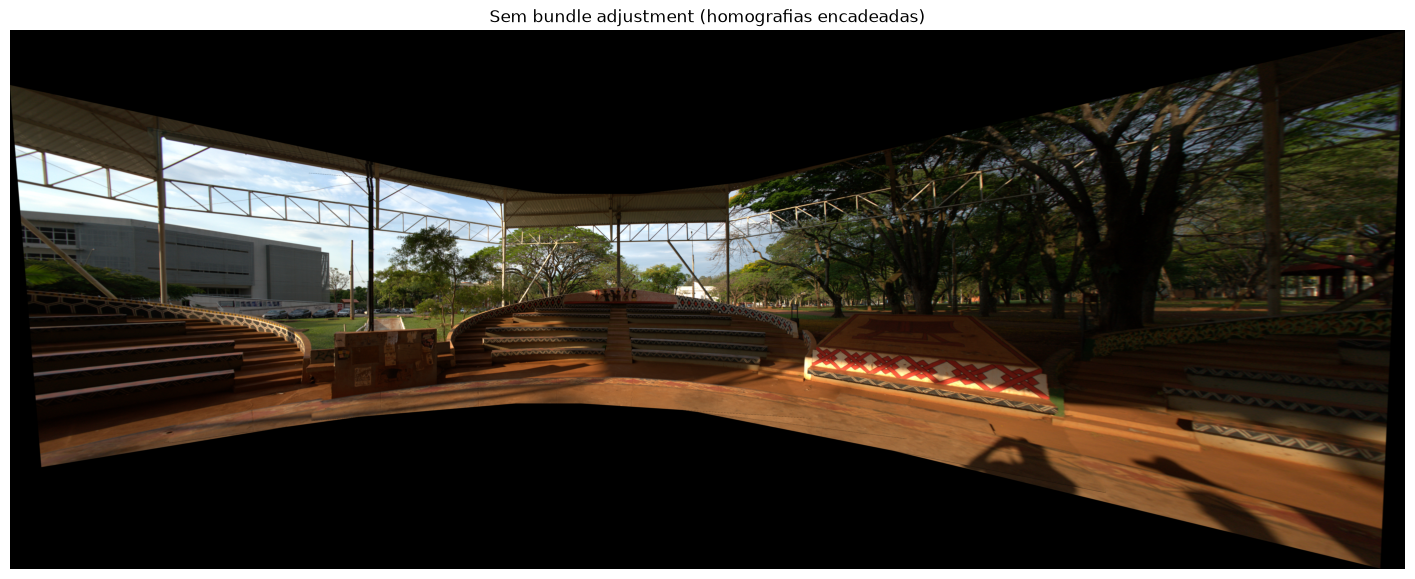

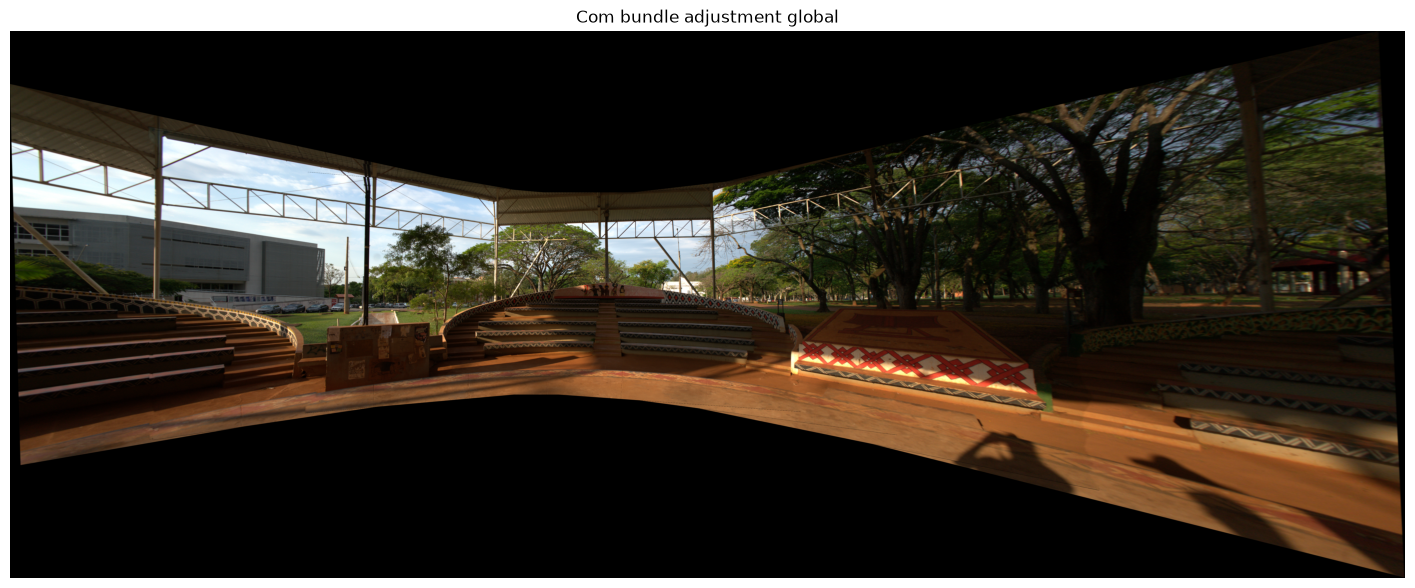

In [11]:
# Aplica o bundle adjustment sobre o resultado da secao Teste e compara
if "resultado" in globals():
    panorama_ba, H_ba, ba_info = apply_bundle_adjustment(resultado)
    show_image(resultado["panorama"], "Sem bundle adjustment (homografias encadeadas)")
    show_image(panorama_ba, "Com bundle adjustment global")
else:
    print("Execute primeiro a secao Teste (ou chame run_pipeline(..., use_bundle_adjustment=True)).")

### Extra 2

### Extra 3

In [12]:
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve

_BGR_LUMA = np.array([0.114, 0.587, 0.299], dtype=np.float64)
_EPS = 1e-3


def _to_intensity(img_u8, linearize=True, gamma=2.2):
    x = img_u8.astype(np.float32)
    return 255.0 * (x / 255.0) ** gamma if linearize else x


def _pixel_means(pixels, per_channel):
    m = pixels.reshape(-1, 3).mean(axis=0).astype(np.float64)
    return m if per_channel else np.full(3, m @ _BGR_LUMA)


def _prepare_stats(warped_list, masks, max_side=1500, linearize=True, gamma=2.2,
                   sat_low=5, sat_high=250):
    """Versoes reduzidas das imagens warpeadas (em intensidade) + mascaras de pixels confiaveis."""
    H, W = masks[0].shape[:2]
    s = min(1.0, max_side / max(H, W))
    size = (max(1, int(round(W * s))), max(1, int(round(H * s))))
    imgs, valids = [], []
    for w, m in zip(warped_list, masks):
        ws = cv2.resize(w, size, interpolation=cv2.INTER_AREA) if s < 1 else w
        ms = cv2.resize(m, size, interpolation=cv2.INTER_NEAREST) if s < 1 else m
        ms = cv2.erode((ms > 0).astype(np.uint8), np.ones((3, 3), np.uint8)).astype(bool)
        unsat = np.all((ws >= sat_low) & (ws <= sat_high), axis=2)
        imgs.append(_to_intensity(ws, linearize, gamma))
        valids.append(ms & unsat)
    return imgs, valids, s


def _solve_log_system(n_nodes, data_terms, smooth_terms, prior_w):
    """
    Minimiza  sum w (x_a - x_b - d)^2 + sum w_s (x_a - x_b)^2 + sum_k prior_w[k] x_k^2
    para x (n_nodes, 3). data_terms: lista de (a, b, w, d[3]); smooth_terms: (a, b, w).
    """
    rows, cols, vals = [], [], []
    B = np.zeros((n_nodes, 3))
    for a, b, w, d in data_terms:
        rows += [a, b, a, b]; cols += [a, b, b, a]; vals += [w, w, -w, -w]
        B[a] += w * d
        B[b] -= w * d
    for a, b, w in smooth_terms:
        rows += [a, b, a, b]; cols += [a, b, b, a]; vals += [w, w, -w, -w]
    diag = np.arange(n_nodes)
    A = coo_matrix((np.concatenate([vals, prior_w]),
                    (np.concatenate([rows, diag]).astype(int), np.concatenate([cols, diag]).astype(int))),
                   shape=(n_nodes, n_nodes)).tocsc()
    X = spsolve(A, B)
    return np.asarray(X).reshape(n_nodes, 3)


def estimate_gains(imgs, valids, method="log", per_channel=True, prior=0.02,
                   sigma_n=10.0, sigma_g=0.1, min_overlap=50):
    """
    Ganho global por imagem. Retorna gains (n, 3) e as estatisticas das sobreposicoes.
    prior (method="log"): peso relativo que puxa log g -> 0 (so fixa a escala global).
    """
    n = len(imgs)
    overlaps = {}
    for i in range(n):
        for j in range(i + 1, n):
            ov = valids[i] & valids[j]
            N = int(ov.sum())
            if N >= min_overlap:
                overlaps[(i, j)] = (N, _pixel_means(imgs[i][ov], per_channel),
                                    _pixel_means(imgs[j][ov], per_channel))

    if method == "log":
        data, n_tot = [], np.zeros(n)
        for (i, j), (N, Ii, Ij) in overlaps.items():
            data.append((i, j, float(N), np.log(Ij + _EPS) - np.log(Ii + _EPS)))
            n_tot[i] += N
            n_tot[j] += N
        x = _solve_log_system(n, data, [], prior * n_tot + 1.0)
        return np.exp(x), overlaps

    if method == "brown_lowe":
        alpha, beta = 1.0 / sigma_n ** 2, 1.0 / sigma_g ** 2
        A, b = np.zeros((3, n, n)), np.zeros((3, n))
        for (i, j), (N, Ii, Ij) in overlaps.items():
            for a, c, Ia, Ic in ((i, j, Ii, Ij), (j, i, Ij, Ii)):
                A[:, a, a] += N * (2 * alpha * Ia ** 2 + beta)
                A[:, a, c] -= 2 * alpha * N * Ia * Ic
                b[:, a] += beta * N
        idx = np.arange(n)
        A[:, idx, idx] += beta  # imagens sem sobreposicao ficam com ganho 1
        b += beta
        return np.stack([np.linalg.solve(A[c], b[c]) for c in range(3)], axis=1), overlaps

    raise ValueError(f"method desconhecido: {method}")


def estimate_block_gains(imgs, valids, block=32, per_channel=True, prior=0.1, smooth=1.0,
                         min_pixels=20):
    """
    Ganho residual (log) por (imagem, bloco do canvas).
    Retorna log_grids (n, by, bx, 3) e present (n, by, bx) = blocos onde a imagem existe.
    """
    n = len(imgs)
    H, W = valids[0].shape
    by, bx = -(-H // block), -(-W // block)
    nb = by * bx
    node = lambda i, y, x: i * nb + y * bx + x

    counts = np.zeros((n, by, bx))
    for i in range(n):
        pad = np.zeros((by * block, bx * block), np.float32)
        pad[:H, :W] = valids[i]
        counts[i] = pad.reshape(by, block, bx, block).sum(axis=(1, 3))
    present = counts >= min_pixels

    data = []
    for y in range(by):
        for x in range(bx):
            sl = (slice(y * block, (y + 1) * block), slice(x * block, (x + 1) * block))
            here = [i for i in range(n) if present[i, y, x]]
            for p, i in enumerate(here):
                for j in here[p + 1:]:
                    ov = valids[i][sl] & valids[j][sl]
                    N = int(ov.sum())
                    if N < min_pixels:
                        continue
                    Ii = _pixel_means(imgs[i][sl][ov], per_channel)
                    Ij = _pixel_means(imgs[j][sl][ov], per_channel)
                    data.append((node(i, y, x), node(j, y, x), float(N),
                                 np.log(Ij + _EPS) - np.log(Ii + _EPS)))

    # suavidade entre blocos vizinhos da mesma imagem
    smooth_terms = []
    for i in range(n):
        for y in range(by):
            for x in range(bx):
                if not present[i, y, x]:
                    continue
                for yy, xx in ((y + 1, x), (y, x + 1)):
                    if yy < by and xx < bx and present[i, yy, xx]:
                        w = smooth * min(counts[i, y, x], counts[i, yy, xx])
                        smooth_terms.append((node(i, y, x), node(i, yy, xx), w))

    prior_w = prior * counts.ravel() + 1.0
    x = _solve_log_system(n * nb, data, smooth_terms, prior_w)
    return x.reshape(n, by, bx, 3), present


def _smooth_log_grid(log_grid, present):
    """Suavizacao normalizada (so blocos onde a imagem existe) + extrapolacao para as bordas."""
    k = np.array([0.25, 0.5, 0.25], dtype=np.float32)
    num = (log_grid * present[..., None]).astype(np.float32)
    den = present.astype(np.float32)
    for _ in range(2):
        num = cv2.sepFilter2D(num, -1, k, k, borderType=cv2.BORDER_REPLICATE)
        den = cv2.sepFilter2D(den, -1, k, k, borderType=cv2.BORDER_REPLICATE)
    return num / np.maximum(den, 1e-6)[..., None]


def _apply_gain(warped, mask, gain, log_grid=None, scale=1.0, block=32,
                linearize=True, gamma=2.2):
    """
    Aplica ganho global `gain` (3,) e, opcionalmente, o mapa de blocos (log_grid) interpolado
    apenas no bounding box da imagem (economiza memoria).
    """
    out = np.zeros_like(warped)
    x0, y0, w, h = cv2.boundingRect((mask > 0).astype(np.uint8))
    if w == 0 or h == 0:
        return out
    g = np.asarray(gain, np.float32).reshape(1, 1, 3)
    if log_grid is not None:
        # pixel (u, v) do bbox -> coordenada na grade de blocos (centros dos blocos)
        a = scale / block
        M = np.float32([[a, 0, (x0 * scale + 0.5) / block - 0.5],
                        [0, a, (y0 * scale + 0.5) / block - 0.5]])
        gmap = cv2.warpAffine(log_grid.astype(np.float32), M, (w, h),
                              flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP,
                              borderMode=cv2.BORDER_REPLICATE)
        g = g * np.exp(gmap.reshape(h, w, 3))

    roi = warped[y0:y0 + h, x0:x0 + w].astype(np.float32) / 255.0
    if linearize:
        roi = np.clip((roi ** gamma) * g, 0, 1) ** (1.0 / gamma)
    else:
        roi = np.clip(roi * g, 0, 1)
    roi = (roi * 255.0 + 0.5).astype(np.uint8)
    roi[mask[y0:y0 + h, x0:x0 + w] == 0] = 0
    out[y0:y0 + h, x0:x0 + w] = roi
    return out


def overlap_intensity_error(warped_list, masks, max_side=1500):
    """Diferenca absoluta media (0-255) entre imagens nas sobreposicoes. Menor = mais uniforme."""
    imgs, valids, _ = _prepare_stats(warped_list, masks, max_side, linearize=False)
    total, count, per_pair = 0.0, 0, {}
    for i in range(len(imgs)):
        for j in range(i + 1, len(imgs)):
            ov = valids[i] & valids[j]
            N = int(ov.sum())
            if N < 50:
                continue
            e = float(np.abs(imgs[i][ov] - imgs[j][ov]).mean())
            per_pair[(i, j)] = e
            total += e * N
            count += N
    return (total / count if count else float("nan")), per_pair


def compensate_exposure(warped_list, masks, mode="gain+blocks", method="log", linearize=True,
                        gamma=2.2, per_channel=True, block=32, block_prior=0.1, block_smooth=1.0,
                        max_side=1500, inplace=False, **gain_kwargs):
    """
    Compensa a exposicao de imagens ja warpeadas no canvas comum.
    mode: "gain" (ganho global), "blocks" (so blocos) ou "gain+blocks".
    Retorna (lista de imagens compensadas, info). inplace=True libera as originais (menos memoria).
    """
    if mode not in ("gain", "blocks", "gain+blocks"):
        raise ValueError(f"mode invalido: {mode}")
    err_before, pairs_before = overlap_intensity_error(warped_list, masks, max_side)
    imgs, valids, scale = _prepare_stats(warped_list, masks, max_side, linearize, gamma)
    n = len(imgs)

    gains = np.ones((n, 3))
    if "gain" in mode:
        gains, _ = estimate_gains(imgs, valids, method=method, per_channel=per_channel, **gain_kwargs)

    log_grids = None
    if "blocks" in mode:
        imgs_g = [im * g.astype(np.float32) for im, g in zip(imgs, gains)]
        raw, present = estimate_block_gains(imgs_g, valids, block, per_channel,
                                            prior=block_prior, smooth=block_smooth)
        log_grids = [_smooth_log_grid(raw[i], present[i]) for i in range(n)]

    out = warped_list if inplace else [None] * n
    for i in range(n):
        out[i] = _apply_gain(warped_list[i], masks[i], gains[i],
                             None if log_grids is None else log_grids[i],
                             scale, block, linearize, gamma)

    err_after, pairs_after = overlap_intensity_error(out, masks, max_side)
    info = {"gains": gains, "block_log_gains": log_grids, "mode": mode, "method": method,
            "err_before": err_before, "err_after": err_after,
            "pairs_before": pairs_before, "pairs_after": pairs_after}
    return out, info


def compose_panorama_exposure(images, H_list, feather_width=15, mode="gain+blocks",
                              erode_px=2, remove_ghosts=True, return_naive=True, names=None,
                              verbose=True, **kwargs):
    """
    Etapa 6 com compensacao de exposicao: warp -> compensacao -> composicao com
    costura otima (mesmas funcoes da Etapa 6). Retorna (panorama, ingenuo, info).
    return_naive=False pula a composicao ingenua (economiza bastante memoria) e retorna None.
    """
    canvas_size, translation = get_canvas_bounds(images, H_list)
    kernel = np.ones((2 * erode_px + 1, 2 * erode_px + 1), np.uint8) if erode_px > 0 else None
    warped_list, mask_list = [], []
    for img, H in zip(images, H_list):
        warped, mask = warp_to_canvas(img, H, translation, canvas_size)
        mask = np.where(mask == 255, 255, 0).astype(np.uint8)  # so pixels 100% dentro da imagem
        if kernel is not None:
            mask = cv2.erode(mask, kernel)
        warped[mask == 0] = 0
        warped_list.append(warped)
        mask_list.append(mask)

    comp, info = compensate_exposure(warped_list, mask_list, mode=mode, inplace=True, **kwargs)

    if verbose:
        label = (lambda i: names[i]) if names is not None else (lambda i: f"img{i}")
        print(f"  Compensacao de exposicao ({mode}, {info['method']}):")
        for i, g in enumerate(info["gains"]):
            print(f"    {label(i)}: ganho B={g[0]:.3f} G={g[1]:.3f} R={g[2]:.3f}")
        print(f"    Diferenca media nas sobreposicoes: {info['err_before']:.2f} -> "
              f"{info['err_after']:.2f} niveis de cinza")

    naive = naive_composite(comp, mask_list) if (return_naive or not remove_ghosts) else None
    if not remove_ghosts:
        return naive.copy(), naive, info

    panorama, panorama_mask = comp[0].copy(), mask_list[0].copy()
    for warped, mask in zip(comp[1:], mask_list[1:]):
        panorama, panorama_mask = blend_pair_with_seam(panorama, panorama_mask, warped, mask,
                                                       feather_width)
    return panorama, naive, info


def simulate_exposure_variation(images, low=0.45, high=1.8, color_cast=0.08, vignette=0.3,
                                gamma=2.2, seed=0):
    """Para testes: altera exposicao, balanco de branco e aplica vinheta em cada imagem."""
    rng = np.random.default_rng(seed)
    out, factors = [], []
    for img in images:
        h, w = img.shape[:2]
        f = rng.uniform(low, high) * (1 + rng.uniform(-color_cast, color_cast, 3))
        yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
        r2 = ((xx - w / 2) / (w / 2)) ** 2 + ((yy - h / 2) / (h / 2)) ** 2
        vig = (1 - vignette * r2 / 2)[..., None]
        lin = (img.astype(np.float32) / 255.0) ** gamma * f.astype(np.float32) * vig
        out.append((np.clip(lin, 0, 1) ** (1 / gamma) * 255 + 0.5).astype(np.uint8))
        factors.append(f)
    return out, np.array(factors)

Fatores de exposicao simulados: {'DSC03736.png': 1.17, 'DSC03738.png': 0.88, 'DSC03737.png': 1.18, 'DSC03739.png': 0.9, 'DSC03740.png': 0.61, 'DSC03741.png': 1.48, 'DSC03742.png': 1.75, 'DSC03743.png': 0.67, 'DSC03744.png': 1.35}


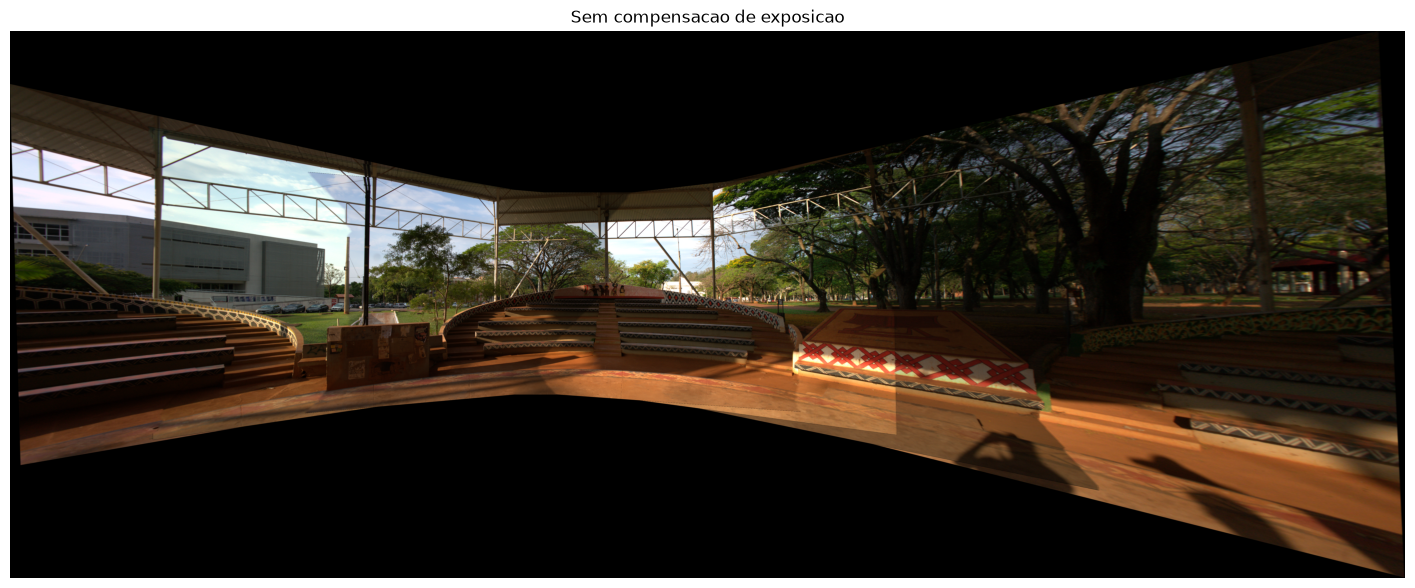

  Compensacao de exposicao (gain, log):
    DSC03736.png: ganho B=1.042 G=1.212 R=1.121
    DSC03738.png: ganho B=1.298 G=1.238 R=1.372
    DSC03737.png: ganho B=1.030 G=0.934 R=1.004
    DSC03739.png: ganho B=1.040 G=1.140 R=1.142
    DSC03740.png: ganho B=1.398 G=1.394 R=1.360
    DSC03741.png: ganho B=0.665 G=0.619 R=0.564
    DSC03742.png: ganho B=0.529 G=0.516 R=0.537
    DSC03743.png: ganho B=1.512 G=1.587 R=1.659
    DSC03744.png: ganho B=0.860 G=0.834 R=0.751
    Diferenca media nas sobreposicoes: 18.25 -> 11.22 niveis de cinza


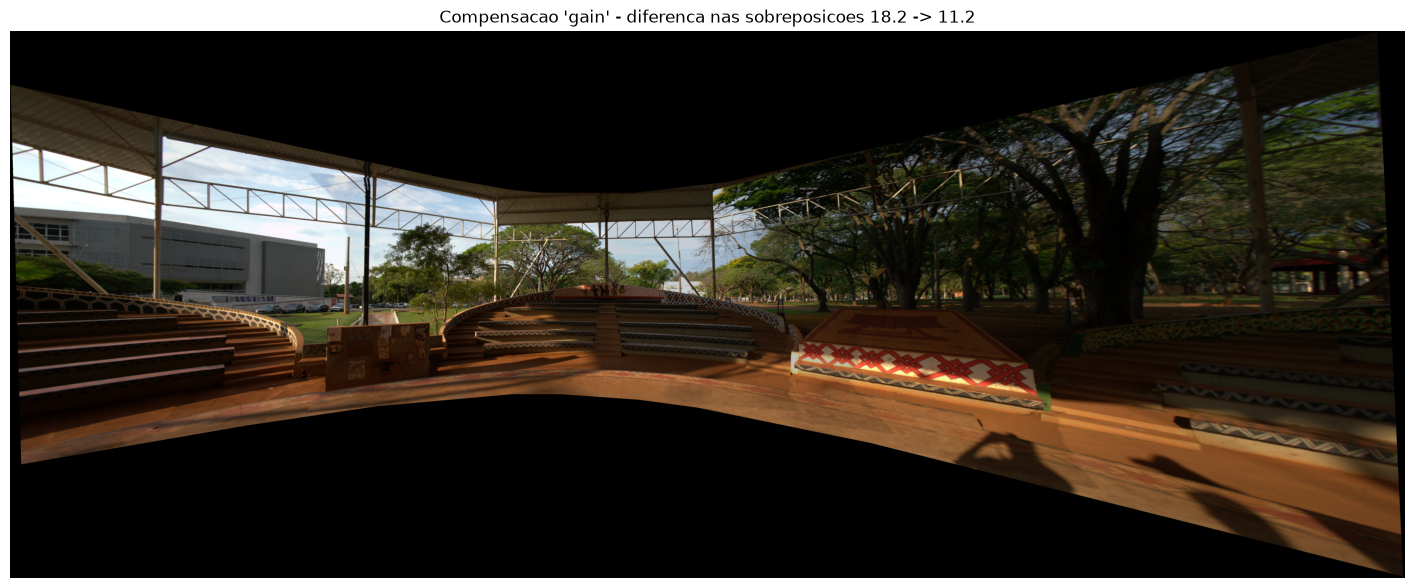

  Compensacao de exposicao (gain+blocks, log):
    DSC03736.png: ganho B=1.042 G=1.212 R=1.121
    DSC03738.png: ganho B=1.298 G=1.238 R=1.372
    DSC03737.png: ganho B=1.030 G=0.934 R=1.004
    DSC03739.png: ganho B=1.040 G=1.140 R=1.142
    DSC03740.png: ganho B=1.398 G=1.394 R=1.360
    DSC03741.png: ganho B=0.665 G=0.619 R=0.564
    DSC03742.png: ganho B=0.529 G=0.516 R=0.537
    DSC03743.png: ganho B=1.512 G=1.587 R=1.659
    DSC03744.png: ganho B=0.860 G=0.834 R=0.751
    Diferenca media nas sobreposicoes: 18.25 -> 7.95 niveis de cinza


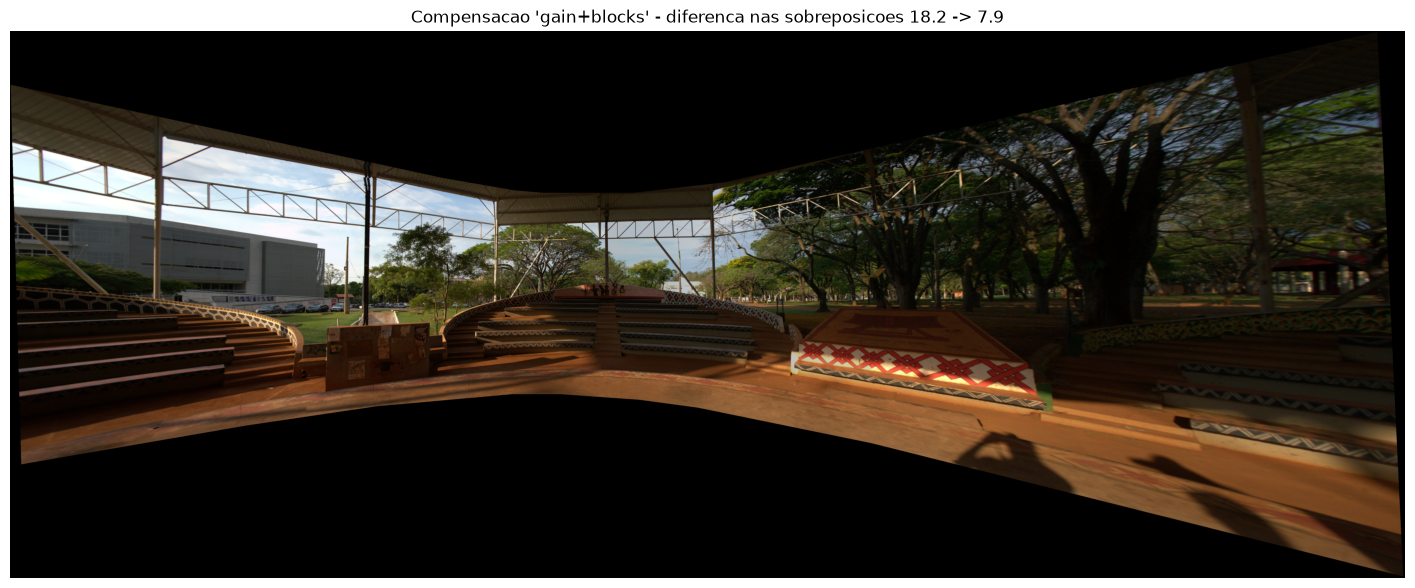

In [13]:
# Compara o panorama sem e com compensacao de exposicao, usando o resultado do Teste
# (e as homografias do Extra 1, se ele foi executado).
SIMULAR_EXPOSICAO = True   # True: altera artificialmente exposicao/cor/vinheta p/ evidenciar o efeito

if "resultado" in globals():
    chain = [i for i in resultado["order"] if i in resultado["H_to_ref"]]
    H_usado = H_ba if "H_ba" in globals() else resultado["H_to_ref"]
    imgs = [resultado["images"][i] for i in chain]
    nomes = [resultado["filenames"][i] for i in chain]
    Hs = [H_usado[i] for i in chain]
    fw = resultado["params"]["feather_width"]
    out_dir = resultado["params"]["output_dir"]

    if SIMULAR_EXPOSICAO:
        imgs, fatores = simulate_exposure_variation(imgs, seed=1)
        print("Fatores de exposicao simulados:",
              {n: round(float(f.mean()), 2) for n, f in zip(nomes, fatores)})

    pano_sem, _ = compose_panorama(imgs, Hs, feather_width=fw)
    cv2.imwrite(os.path.join(out_dir, "extra3_sem_compensacao.png"), pano_sem)
    show_image(pano_sem, "Sem compensacao de exposicao")
    del pano_sem

    for modo, arquivo in [("gain", "extra3_ganho_global.png"),
                          ("gain+blocks", "extra3_ganho_global_blocos.png")]:
        pano_exp, _, info_exp = compose_panorama_exposure(imgs, Hs, feather_width=fw, mode=modo,
                                                     return_naive=False, names=nomes)
        cv2.imwrite(os.path.join(out_dir, arquivo), pano_exp)
        show_image(pano_exp, f"Compensacao '{modo}' - diferenca nas sobreposicoes "
                             f"{info_exp['err_before']:.1f} -> {info_exp['err_after']:.1f}")
        del pano_exp
else:
    print("Execute primeiro a secao Teste (ou chame run_pipeline(..., exposure_compensation='gain+blocks')).")

### Extra 4

In [14]:
import numpy as np
import cv2


def stitch_two_opencv(left_img, right_img):
    # Use OpenCV Stitcher
    stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

    # Order matters: left to right
    stitch_status, panorama = stitcher.stitch([left_img, right_img])
    if stitch_status == cv2.Stitcher_OK:
        return cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)
    else:
        # Simple horizontal concatenation
        panorama = np.hstack((left_img, right_img))
        return cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)

#### Extra 4a - cv2.Stitcher com N imagens

In [19]:
# ============================================================
# Extra 4a - cv2.Stitcher com N imagens (> 2)
# ============================================================
# O Stitcher do OpenCV descobre sozinho quais imagens se sobrepoem (a ordem
# nao importa), faz bundle adjustment de camera, correcao de onda e blending
# multibanda. Serve como baseline para comparar com o nosso pipeline.

STITCHER_ERRORS = {
    cv2.Stitcher_ERR_NEED_MORE_IMGS: "poucas imagens com sobreposicao suficiente",
    cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL: "falha ao estimar homografia (poucos matches)",
    cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL: "falha no bundle adjustment dos parametros de camera",
}


def crop_black_borders(pano):
    """Remove as bordas pretas encontrando o maior retangulo totalmente preenchido."""
    pano = cv2.copyMakeBorder(pano, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=(0, 0, 0))
    gray = cv2.cvtColor(pano, cv2.COLOR_BGR2GRAY)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return pano
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))

    rect = np.zeros_like(th)
    cv2.rectangle(rect, (x, y), (x + w - 1, y + h - 1), 255, -1)
    sub = cv2.subtract(rect, th)
    while cv2.countNonZero(sub) > 0:
        eroded = cv2.erode(rect, None)
        if cv2.countNonZero(eroded) == 0:
            break
        rect = eroded
        sub = cv2.subtract(rect, th)

    x, y, w, h = cv2.boundingRect(rect)
    return pano[y:y + h, x:x + w]


def stitch_opencv(images, mode="panorama", conf_thresh=1.0, crop=False):
    """Stitching de N imagens (lista BGR) com cv2.Stitcher. Retorna o panorama BGR."""
    if len(images) < 2:
        raise ValueError("Sao necessarias pelo menos 2 imagens.")
    cv_mode = cv2.Stitcher_PANORAMA if mode == "panorama" else cv2.Stitcher_SCANS
    stitcher = cv2.Stitcher_create(cv_mode)
    stitcher.setPanoConfidenceThresh(conf_thresh)

    status, pano = stitcher.stitch(images)
    if status != cv2.Stitcher_OK:
        raise RuntimeError(f"cv2.Stitcher falhou (codigo {status}): "
                           f"{STITCHER_ERRORS.get(status, 'erro desconhecido')}. "
                           "Tente diminuir conf_thresh (ex.: 0.5) ou mode='scans'.")
    return crop_black_borders(pano) if crop else pano


def run_opencv_stitcher(input_dir, output_dir, mode="panorama", conf_thresh=1.0,
                        crop=False, max_width=1500):
    os.makedirs(output_dir, exist_ok=True)
    images, filenames = load_images(input_dir, shuffle=False)
    if max_width:
        images = [cv2.resize(im, None, fx=max_width / im.shape[1], fy=max_width / im.shape[1],
                             interpolation=cv2.INTER_AREA) if im.shape[1] > max_width else im
                  for im in images]
    print(f"[cv2.Stitcher] {len(images)} imagens, modo={mode}")
    pano = stitch_opencv(images, mode=mode, conf_thresh=conf_thresh, crop=crop)
    out = os.path.join(output_dir, "panorama_opencv_stitcher.png")
    cv2.imwrite(out, pano)
    print(f"  Panorama salvo em {out} ({pano.shape[1]}x{pano.shape[0]})")
    return pano

#### Extra 4b - SuperPoint + SuperGlue e LoFTR

In [20]:
# ============================================================
# Extra 4b - Matchers com deep learning: SuperPoint + SuperGlue e LoFTR
# ============================================================
# Dependencias:  pip install torch kornia "transformers>=4.51" pillow certifi
#   - SuperPoint+SuperGlue: HuggingFace transformers (magic-leap-community/superglue_outdoor)
#     (obs.: os pesos oficiais do SuperGlue tem licenca NAO comercial)
#   - LoFTR: kornia.feature.LoFTR (pesos "outdoor" ou "indoor")
#   - EfficientLoFTR (alternativa ao LoFTR, via HuggingFace): zju-community/efficientloftr
# Todos tem a mesma interface:  pts0, pts1 = matcher(img0_bgr, img1_bgr)
# (arrays Nx2 float32, em coordenadas da resolucao ORIGINAL das imagens).
import ssl
import urllib.request

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def _load_hf_keypoint_matcher(model_name):
    """Carrega processor + modelo de keypoint matching do HuggingFace.
    Versoes recentes do transformers NAO mapeiam SuperGlue/EfficientLoFTR em AutoModel
    (era o erro 'Unrecognized configuration class ... for AutoModel');
    o correto e AutoModelForKeypointMatching."""
    from transformers import AutoImageProcessor
    try:
        from transformers import AutoModelForKeypointMatching as _Auto
    except ImportError:  # transformers antigo
        from transformers import AutoModel as _Auto
    processor = AutoImageProcessor.from_pretrained(model_name)
    model = _Auto.from_pretrained(model_name).to(DEVICE).eval()
    return processor, model


class HFKeypointMatcher:
    """Matcher generico para modelos de keypoint matching do HuggingFace."""

    def __init__(self, model_name, threshold=0.2, name="hf"):
        self.processor, self.model = _load_hf_keypoint_matcher(model_name)
        self.threshold = threshold
        self.name = name

    @torch.no_grad()
    def __call__(self, img0, img1):
        from PIL import Image
        p0 = Image.fromarray(cv2.cvtColor(img0, cv2.COLOR_BGR2RGB))
        p1 = Image.fromarray(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

        inputs = self.processor([[p0, p1]], return_tensors="pt").to(DEVICE)
        outputs = self.model(**inputs)

        sizes = [[(img0.shape[0], img0.shape[1]), (img1.shape[0], img1.shape[1])]]
        res = self.processor.post_process_keypoint_matching(outputs, sizes, threshold=self.threshold)[0]
        pts0 = res["keypoints0"].cpu().numpy().astype(np.float32)
        pts1 = res["keypoints1"].cpu().numpy().astype(np.float32)
        return pts0, pts1


class SuperGlueMatcher(HFKeypointMatcher):
    """SuperPoint (detector/descritor) + SuperGlue (matcher por atencao em grafo)."""

    def __init__(self, model_name="magic-leap-community/superglue_outdoor", threshold=0.2):
        super().__init__(model_name, threshold, name="superglue")


class EfficientLoFTRMatcher(HFKeypointMatcher):
    """EfficientLoFTR (versao mais rapida do LoFTR), via HuggingFace."""

    def __init__(self, model_name="zju-community/efficientloftr", threshold=0.2):
        super().__init__(model_name, threshold, name="efficientloftr")


def _ensure_kornia_loftr_weights(pretrained="outdoor", allow_insecure_download=False):
    """
    O kornia baixa os pesos do LoFTR de cmp.felk.cvut.cz. Em alguns Windows o Python nao
    valida o certificado desse servidor (CERTIFICATE_VERIFY_FAILED). Aqui baixamos o arquivo
    para o cache do torch.hub usando os certificados do pacote `certifi`; depois o kornia o
    encontra no cache e nao tenta baixar de novo.
    """
    try:
        from kornia.feature.loftr.loftr import urls as loftr_urls
        url = loftr_urls[pretrained]
    except Exception:
        url = f"http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_{pretrained}.ckpt"

    ckpt_dir = os.path.join(torch.hub.get_dir(), "checkpoints")
    path = os.path.join(ckpt_dir, os.path.basename(url))
    if os.path.exists(path) and os.path.getsize(path) > 0:
        return path
    os.makedirs(ckpt_dir, exist_ok=True)

    contexts = []
    try:
        import certifi
        contexts.append(("certifi", ssl.create_default_context(cafile=certifi.where())))
    except ImportError:
        pass
    contexts.append(("sistema", ssl.create_default_context()))
    if allow_insecure_download:
        contexts.append(("SEM verificacao SSL", ssl._create_unverified_context()))

    last_err = None
    for label, ctx in contexts:
        try:
            print(f"  Baixando pesos do LoFTR ({label}): {url}")
            with urllib.request.urlopen(url, context=ctx, timeout=60) as r, open(path + ".part", "wb") as f:
                while chunk := r.read(1 << 20):
                    f.write(chunk)
            os.replace(path + ".part", path)
            return path
        except Exception as e:
            last_err = e
            if os.path.exists(path + ".part"):
                os.remove(path + ".part")
    raise RuntimeError(
        f"Nao foi possivel baixar os pesos do LoFTR ({last_err}).\n"
        f"  Opcao 1: baixe manualmente pelo navegador {url}\n"
        f"           e salve em: {path}\n"
        f"  Opcao 2: LoFTRMatcher(allow_insecure_download=True)  (desativa a verificacao SSL)\n"
        f"  Opcao 3: use method='efficientloftr' (pesos vem do HuggingFace)"
    )


class LoFTRMatcher:
    """LoFTR (kornia): matching denso sem detector (bom em regioes com pouca textura)."""

    def __init__(self, pretrained="outdoor", max_side=840, conf_min=0.5,
                 allow_insecure_download=False):
        import kornia.feature as KF
        _ensure_kornia_loftr_weights(pretrained, allow_insecure_download)
        self.model = KF.LoFTR(pretrained=pretrained).to(DEVICE).eval()
        self.max_side = max_side
        self.conf_min = conf_min
        self.name = "loftr"

    def _prepare(self, img):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = gray.shape
        scale = min(1.0, self.max_side / max(h, w))
        # LoFTR exige dimensoes multiplas de 8
        nw = max(8, int(round(w * scale / 8)) * 8)
        nh = max(8, int(round(h * scale / 8)) * 8)
        g = cv2.resize(gray, (nw, nh), interpolation=cv2.INTER_AREA)
        t = torch.from_numpy(g).float()[None, None] / 255.0
        return t.to(DEVICE), np.array([w / nw, h / nh], dtype=np.float32)

    @torch.no_grad()
    def __call__(self, img0, img1):
        t0, s0 = self._prepare(img0)
        t1, s1 = self._prepare(img1)
        out = self.model({"image0": t0, "image1": t1})
        conf = out["confidence"].cpu().numpy()
        keep = conf > self.conf_min
        pts0 = out["keypoints0"].cpu().numpy()[keep] * s0   # volta para a resolucao original
        pts1 = out["keypoints1"].cpu().numpy()[keep] * s1
        return pts0.astype(np.float32), pts1.astype(np.float32)


def create_deep_matcher(method="superglue", fallback=True, **kwargs):
    """method: 'superglue', 'loftr' ou 'efficientloftr'.
    Com fallback=True, se os pesos do LoFTR (kornia) nao puderem ser baixados,
    usa o EfficientLoFTR do HuggingFace."""
    method = method.lower()
    if method == "superglue":
        return SuperGlueMatcher(**kwargs)
    if method == "efficientloftr":
        return EfficientLoFTRMatcher(**kwargs)
    if method == "loftr":
        try:
            return LoFTRMatcher(**kwargs)
        except RuntimeError as e:
            if not fallback:
                raise
            print(f"  {e}\n  -> Usando EfficientLoFTR (HuggingFace) no lugar do LoFTR do kornia.")
            return EfficientLoFTRMatcher()
    raise ValueError(f"Matcher desconhecido: {method}")

#### Extra 4c - Pipeline completo com matchers profundos

In [21]:
# ============================================================
# Extra 4c - Pipeline completo com SuperGlue / LoFTR
# ============================================================
# Substitui as Etapas 2-3 (SIFT/ORB + ratio test) pelos matchers profundos e
# reaproveita o resto do pipeline: grafo de vizinhanca, deteccao de intrusas,
# ordenacao (Etapa 4), homografias compostas (Etapa 5), bundle adjustment
# (Extra 1) e composicao com costura otima (Etapa 6).


def build_connectivity_matrix_deep(images, matcher, ransac_thresh=4.0, min_matches=8,
                                   max_pts_per_pair=300, seed=0, names=None):
    """
    Versao da Etapa 4 com matcher profundo. Retorna:
      connectivity[i, j] = n. de inliers,
      homographies[(i, j)] = H_i->j (i < j),
      pairs[(i, j)] = (pts_i, pts_j) inliers (subamostrados), usados no bundle adjustment.
    """
    rng = np.random.default_rng(seed)
    n = len(images)
    connectivity = np.zeros((n, n), dtype=int)
    homographies, pairs = {}, {}
    for i in range(n):
        for j in range(i + 1, n):
            pts_i, pts_j = matcher(images[i], images[j])
            n_inl = 0
            if len(pts_i) >= max(4, min_matches):
                H, mask = cv2.findHomography(pts_i, pts_j, cv2.RANSAC, ransac_thresh)
                if H is not None:
                    inl = mask.ravel().astype(bool)
                    n_inl = int(inl.sum())
                    homographies[(i, j)] = H
                    pi, pj = pts_i[inl], pts_j[inl]
                    if len(pi) > max_pts_per_pair:
                        sel = rng.choice(len(pi), max_pts_per_pair, replace=False)
                        pi, pj = pi[sel], pj[sel]
                    pairs[(i, j)] = (pi.astype(np.float64), pj.astype(np.float64))
            connectivity[i, j] = connectivity[j, i] = n_inl
            if names is not None:
                print(f"  {names[i]} x {names[j]}: {len(pts_i)} matches, {n_inl} inliers")
    return connectivity, homographies, pairs


def draw_point_matches(img0, img1, pts0, pts1, out_path=None, max_draw=300, seed=0):
    """Visualiza correspondencias dadas como arrays de pontos (sem cv2.KeyPoint)."""
    rng = np.random.default_rng(seed)
    h0, w0 = img0.shape[:2]
    h1, w1 = img1.shape[:2]
    canvas = np.zeros((max(h0, h1), w0 + w1, 3), np.uint8)
    canvas[:h0, :w0], canvas[:h1, w0:] = img0, img1
    idx = rng.permutation(len(pts0))[:max_draw]
    for k in idx:
        c = tuple(int(v) for v in rng.integers(0, 255, 3))
        p0 = tuple(int(v) for v in pts0[k])
        p1 = (int(pts1[k][0]) + w0, int(pts1[k][1]))
        cv2.line(canvas, p0, p1, c, 1, cv2.LINE_AA)
        cv2.circle(canvas, p0, 3, c, -1)
        cv2.circle(canvas, p1, 3, c, -1)
    if out_path:
        cv2.imwrite(out_path, canvas)
    return canvas


def run_pipeline_deep(input_dir, output_dir, method="superglue", matcher=None,
                      ransac_thresh=4.0, min_matches=8, min_inliers=40,
                      feather_width=15, use_bundle_adjustment=True, max_width=1600,
                      exposure_compensation="gain+blocks"):
    """
    Pipeline completo (pasta -> panorama) usando SuperPoint+SuperGlue ou LoFTR.
    `matcher` permite passar um matcher ja instanciado (evita recarregar o modelo).
    """
    out_dir = os.path.join(output_dir, method)
    os.makedirs(out_dir, exist_ok=True)

    print(f"[{method}] Etapa 1 - carregando imagens...")
    images, filenames = load_images(input_dir)
    if max_width:
        images = [cv2.resize(im, None, fx=max_width / im.shape[1], fy=max_width / im.shape[1],
                             interpolation=cv2.INTER_AREA) if im.shape[1] > max_width else im
                  for im in images]

    if matcher is None:
        print(f"[{method}] Carregando modelo em {DEVICE}...")
        matcher = create_deep_matcher(method)

    print(f"\n[{method}] Etapas 2-4 - matching de todos os pares e matriz de conectividade...")
    connectivity, homographies, pairs = build_connectivity_matrix_deep(
        images, matcher, ransac_thresh=ransac_thresh, min_matches=min_matches, names=filenames)
    print(connectivity)
    np.savetxt(os.path.join(out_dir, "matriz_conectividade.csv"), connectivity, fmt="%d", delimiter=",")

    graph = build_neighbor_graph(connectivity, min_inliers=min_inliers)
    intruders = detect_intruders(graph)
    if intruders:
        print(f"Imagens intrusas rejeitadas: {[filenames[i] for i in intruders]}")
    valid_nodes = [i for i in range(len(images)) if i not in intruders]
    order = infer_order(graph, valid_nodes)
    print(f"Ordem inferida: {[filenames[i] for i in order]}")

    # visualizacao dos matches entre vizinhos consecutivos
    for k in range(len(order) - 1):
        i, j = order[k], order[k + 1]
        key, flip = ((i, j), False) if (i, j) in pairs else ((j, i), True)
        if key in pairs:
            pa, pb = pairs[key]
            if flip:
                pa, pb = pb, pa
            draw_point_matches(images[i], images[j], pa, pb,
                               os.path.join(out_dir, f"match_{k}_{filenames[i]}_x_{filenames[j]}.png"))

    print(f"\n[{method}] Etapa 5 - homografias para o referencial comum...")
    ref_index, H_to_ref = choose_reference_image(order, homographies, images)
    print(f"  Imagem de referencia (menor canvas): {filenames[ref_index]}")
    for k in range(len(order) - 1):
        i, j = order[k], order[k + 1]
        H_ij = _get_H(i, j, homographies)
        key = (i, j) if (i, j) in pairs else (j, i)
        if H_ij is not None and key in pairs:
            pa, pb = pairs[key] if key == (i, j) else pairs[key][::-1]
            err = np.linalg.norm(_apply_homography(H_ij, pa) - pb, axis=1).mean()
            print(f"  Par ({filenames[i]}, {filenames[j]}): {connectivity[i, j]} inliers, "
                  f"erro medio {err:.3f} px")

    ba_info = None
    if use_bundle_adjustment:
        print(f"\n[{method}] Extra 1 - bundle adjustment global...")
        valid_pairs = {k: v for k, v in pairs.items() if connectivity[k] >= min_inliers}
        H_to_ref, ba_info = bundle_adjust_homographies(H_to_ref, valid_pairs, ref_index, names=filenames)

    chain = [i for i in order if i in H_to_ref]
    imgs = [images[i] for i in chain]
    Hs = [H_to_ref[i] for i in chain]

    print(f"\n[{method}] Etapa 6 - composicao...")
    w, h = check_canvas_size(imgs, Hs)
    print(f"  Tamanho do canvas: {w}x{h}")
    exposure_info = None
    if exposure_compensation:
        panorama, naive, exposure_info = compose_panorama_exposure(
            imgs, Hs, feather_width=feather_width, mode=exposure_compensation,
            names=[filenames[i] for i in chain])
    else:
        panorama, naive = compose_panorama(imgs, Hs, feather_width=feather_width)
    cv2.imwrite(os.path.join(out_dir, "panorama_ingenuo.png"), naive)
    cv2.imwrite(os.path.join(out_dir, "panorama_final.png"), panorama)
    print(f"  Resultados salvos em {out_dir}")

    return {"images": images, "filenames": filenames, "order": order, "intruders": intruders,
            "connectivity": connectivity, "homographies": homographies, "pairs": pairs,
            "ref_index": ref_index, "H_to_ref": H_to_ref, "ba_info": ba_info,
            "exposure_info": exposure_info,
            "panorama": panorama, "naive": naive}

#### Extra 4d - Execucao e comparacao

In [22]:
# ============================================================
# Extra 4d - Executa e compara os tres metodos na pasta INPUT_DIR
# ============================================================
paineis = {}

try:
    paineis["cv2.Stitcher"] = run_opencv_stitcher(INPUT_DIR, OUTPUT_DIR, conf_thresh=0.8)
except Exception as e:
    print(f"cv2.Stitcher falhou: {e}")

for metodo in ["superglue", "loftr"]:
    try:
        res_deep = run_pipeline_deep(INPUT_DIR, OUTPUT_DIR, method=metodo,
                                     use_bundle_adjustment=True)
        paineis[metodo] = res_deep["panorama"]
    except ImportError as e:
        print(f"{metodo}: dependencia ausente ({e}). Instale: pip install torch kornia transformers pillow")
    except Exception as e:
        print(f"{metodo} falhou: {e}")

for nome, pano in paineis.items():
    show_image(pano, nome)

Ordem de leitura (embaralhada; usada so para referencia/depuracao do usuario):
  indice 0: DSC03736.png
  indice 1: DSC03737.png
  indice 2: DSC03738.png
  indice 3: DSC03739.png
  indice 4: DSC03740.png
  indice 5: DSC03741.png
  indice 6: DSC03742.png
  indice 7: DSC03743.png
  indice 8: DSC03744.png
  indice 9: WhatsApp Image 2026-10-02 at 10.39.58.jpeg
[cv2.Stitcher] 10 imagens, modo=panorama
  Panorama salvo em resultados\panorama_opencv_stitcher.png (3317x1004)
[superglue] Etapa 1 - carregando imagens...
Ordem de leitura (embaralhada; usada so para referencia/depuracao do usuario):
  indice 0: DSC03737.png
  indice 1: DSC03742.png
  indice 2: DSC03741.png
  indice 3: DSC03736.png
  indice 4: DSC03738.png
  indice 5: DSC03740.png
  indice 6: DSC03744.png
  indice 7: DSC03743.png
  indice 8: DSC03739.png
  indice 9: WhatsApp Image 2026-10-02 at 10.39.58.jpeg
[superglue] Carregando modelo em cuda...


Loading weights: 100%|██████████| 363/363 [00:00<00:00, 2589.04it/s]



[superglue] Etapas 2-4 - matching de todos os pares e matriz de conectividade...
  DSC03737.png x DSC03742.png: 115 matches, 54 inliers
  DSC03737.png x DSC03741.png: 278 matches, 157 inliers
  DSC03737.png x DSC03736.png: 700 matches, 534 inliers
  DSC03737.png x DSC03738.png: 845 matches, 768 inliers
  DSC03737.png x DSC03740.png: 386 matches, 237 inliers
  DSC03737.png x DSC03744.png: 31 matches, 6 inliers
  DSC03737.png x DSC03743.png: 42 matches, 9 inliers
  DSC03737.png x DSC03739.png: 599 matches, 420 inliers
  DSC03737.png x WhatsApp Image 2026-10-02 at 10.39.58.jpeg: 7 matches, 0 inliers
  DSC03742.png x DSC03741.png: 685 matches, 562 inliers
  DSC03742.png x DSC03736.png: 98 matches, 23 inliers
  DSC03742.png x DSC03738.png: 109 matches, 57 inliers
  DSC03742.png x DSC03740.png: 469 matches, 296 inliers
  DSC03742.png x DSC03744.png: 569 matches, 364 inliers
  DSC03742.png x DSC03743.png: 719 matches, 539 inliers
  DSC03742.png x DSC03739.png: 288 matches, 159 inliers
  DSC0

KeyboardInterrupt: 